# Lab 9. Exploratory data analysis - exercises

All of the exercises are based on lecture (https://github.com/agazbrzezny/DAT-SWPS-2026/blob/main/statistics.ipynb) and examples presented there.

## Exercises

**Task 1**

Use the [Heart Disease](https://archive.ics.uci.edu/dataset/45/heart+disease) dataset, and then:
* 1.1 Check the data card to see which features are numerical and which are categorical. Check how the pandas library loads this data by default. If a categorical feature is marked as numerical in the table, change it to categorical (pandas has a `category` data type).
* 1.2 Check if there are any missing values in the dataset. If so, before proceeding with the next tasks, prepare a subset of the data that does not contain observations with missing values.

**Task 2**

For the dataset from Task 1, calculate and display:
* 2.1 The distribution of values in the `num` column (Target) – is the data balanced? Display it in a pie chart.
* 2.2 Basic descriptive statistics for each numerical feature (min, max, mean, median, standard deviation, and the 25th, 50th, and 75th percentiles).
* 2.3 The mode for each categorical feature.
* 2.4 Display the Pearson correlation matrix for each numerical feature in the dataset. Also display it on a heatmap using the seaborn library.
* 2.5 From the correlation matrix, display the names of the three features most correlated with the `age` feature (absolute correlation values, excluding the `age` feature itself from the results, which, as we know, will be correlated with itself to a degree of 1).

**Task 3**

Use the [Adult] dataset (https://archive.ics.uci.edu/dataset/2/adult) to complete the following instructions. In this dataset, also set the categorical types for the appropriate columns as described in the dataset documentation.

* 3.1 Perform a t-test for paired samples on the `capital-gain` feature values, assuming the following null hypothesis: the mean value of this feature for `race`=‘White’ is significantly higher than for the other `race` values. Accept or reject the null hypothesis.

* 3.2 Using an ANOVA test, check how statistically significant the difference in the mean value of the `capital-gain` feature is for each value of `race` separately. Report the `p-values` for this test. How should this result be interpreted?

**Task 4**

Perform a chi-square test on the values of the `capital-income` feature for two groups:
* people aged < 40
* people aged >= 40

Display the results of this test.

In [29]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
heart_disease = fetch_ucirepo(id=45) 
  
df = heart_disease.data.original

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  num       303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB


In [49]:
df['sex'] = df['sex'].astype('category')

In [53]:
df[['sex','cp', 'fbs', 'restecg', 'thalach', 'exang', 'slope', 'num']] \
= df[['sex','cp', 'fbs', 'restecg', 'thalach', 'exang', 'slope', 'num']].astype('category')

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   age       303 non-null    int64   
 1   sex       303 non-null    category
 2   cp        303 non-null    category
 3   trestbps  303 non-null    int64   
 4   chol      303 non-null    int64   
 5   fbs       303 non-null    category
 6   restecg   303 non-null    category
 7   thalach   303 non-null    category
 8   exang     303 non-null    category
 9   oldpeak   303 non-null    float64 
 10  slope     303 non-null    category
 11  ca        299 non-null    float64 
 12  thal      301 non-null    float64 
 13  num       303 non-null    category
dtypes: category(8), float64(3), int64(3)
memory usage: 20.5 KB


In [56]:
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
num         0
dtype: int64

In [66]:
df_nona = df.dropna()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,58.0,1,4,120.0,197,0,0,162,0,0.0,1,0.0,3.0,0
1,NaN,NaN,NaN,NaN,234,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [92]:
df_nona

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
297,57,0,4,140,241,0,0,123,1,0.2,2,0.0,7.0,1
298,45,1,1,110,264,0,0,132,0,1.2,2,0.0,7.0,1
299,68,1,4,144,193,1,0,141,0,3.4,2,2.0,7.0,2
300,57,1,4,130,131,0,0,115,1,1.2,2,1.0,7.0,3


In [72]:
df_nona.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='object')

In [78]:
cat_columns = ['sex', 'cp', 'fbs', 'restecg', 'thalach',
       'exang', 'slope', 'num']

In [79]:
df_nona[cat_columns]

,sex,cp,fbs,restecg,thalach,exang,slope,num
0,1,1,1,2,150,0,3,0
1,1,4,0,2,108,1,2,2
2,1,4,0,2,129,1,2,1
3,1,3,0,0,187,0,3,0
4,0,2,0,2,172,0,1,0
...,...,...,...,...,...,...,...,...
297,0,4,0,0,123,1,2,1
298,1,1,0,0,132,0,2,1
299,1,4,1,0,141,0,2,2
300,1,4,0,0,115,1,2,3


In [115]:
df_nona.select_dtypes('category')

,sex,cp,fbs,restecg,thalach,exang,slope,num
0,1,1,1,2,150,0,3,0
1,1,4,0,2,108,1,2,2
2,1,4,0,2,129,1,2,1
3,1,3,0,0,187,0,3,0
4,0,2,0,2,172,0,1,0
...,...,...,...,...,...,...,...,...
297,0,4,0,0,123,1,2,1
298,1,1,0,0,132,0,2,1
299,1,4,1,0,141,0,2,2
300,1,4,0,0,115,1,2,3


In [108]:
df_nona.dtypes[df_nona.dtypes == 'category'].index.values

array(['sex', 'cp', 'fbs', 'restecg', 'thalach', 'exang', 'slope', 'num'],
      dtype=object)

In [91]:
df_nona.dtypes[df_nona.dtypes == 'category'].index.values

array(['sex', 'cp', 'fbs', 'restecg', 'thalach', 'exang', 'slope', 'num'],
      dtype=object)

<Axes: ylabel='count'>

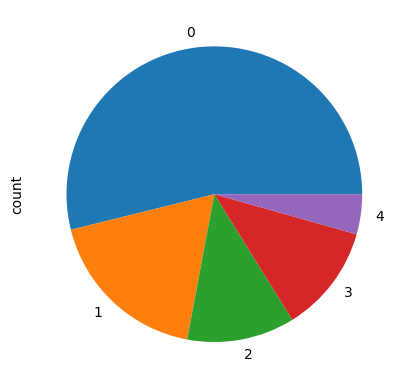

In [65]:
# df_nona['num'].value_counts().plot.pie()
df_nona['num'].value_counts().plot(kind='pie')

In [110]:
df_nona['num'].unique()

[0, 2, 1, 3, 4]
Categories (5, int64): [0, 1, 2, 3, 4]

<Axes: ylabel='count'>

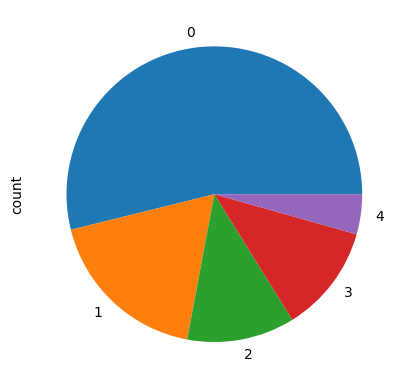

In [113]:
df_nona['num'].value_counts().plot.pie()

In [131]:
df_nona['num'].value_counts()

num
0    160
1     54
2     35
3     35
4     13
Name: count, dtype: int64

In [124]:
sample_1 = df_nona.sample(frac=0.2, random_state=123)['num'].value_counts()
sample_1

num
0    32
1    10
2     8
3     8
4     1
Name: count, dtype: int64

In [125]:
sample_2 = df_nona.sample(frac=0.2, random_state=123, weights=df_nona['num'])['num'].value_counts()
sample_2

num
3    20
2    16
1    15
4     8
0     0
Name: count, dtype: int64

In [130]:
sample_2 / sum(sample_2)

num
3    0.338983
2    0.271186
1    0.254237
4    0.135593
0    0.000000
Name: count, dtype: float64

In [123]:
df_nona['num'].value_counts() / len(df_nona)

num
0    0.538721
1    0.181818
2    0.117845
3    0.117845
4    0.043771
Name: count, dtype: float64